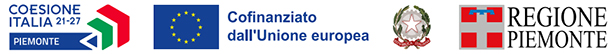


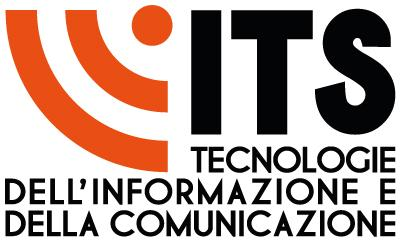




**Unità Formativa (UF):** Strumenti AI e Prompt Engineering

**Docente:** Fabio Giuseppe Antonio Gagliardi

**Titolo argomento:** Esame


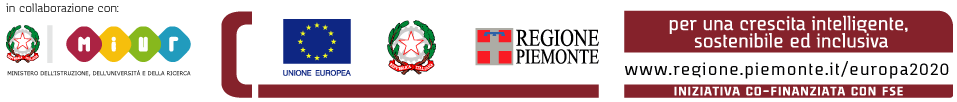

---

**NOME:** Samuele



**COGNOME:** Querio

---

# **REGOLE ESAME**

* **INSERIRE "NOME" E "COGNOME" NEI RISPETTIVI CAMPI**

* **IL CODICE GENERATO AUTOMATICAMENTE DA QUALSIASI LLM SARÀ SOGGETTO A UN ULTERIORE GRADO DI VALUTAZIONE.**

* **LA DCOCUMENTAZIONE NEI COMMENTI È OBBLIGATORIA. OGNI PASSO DELL'IMPLEMENTAZIONE EFFETTUATA DEVE ESSERE OPPORTUNAMENTE COMMENTATO.**
  ```python
  # Step 1: ho caricto il file abc.jpb
  # Step 2: ...
  ```
* **IL CODICE VA SVILUPPATO SOLO E SOLTANTO NELLO SPAZIOE ASSEGNATO:**
    ```python
   pass  # Sostituire con il codice
    ```
    SOSTITUIRE L'ISTRUZIONE pass

* **NON VANNO MODIFICATE LE PARTI PREDEFINITE (COMMENTI E CODICE)**


* **CONSEGNARE SOLO IL FILE DEL NOTEBOOK (.ipynb)**

* **IL FILE DEVE ESSERE RINOMINATO CON IL PROPRIO NOME IN MINUSCOLO COME PREFISSO.**

  es.
  `francesco_totti_esame_saipe_26_27.ipynb`



### Ognuno di questi punti verrà opportunamente valutato. 




---

## Esempi utili

#### In questo esame si farà uso della formattazione delle stringhe in python. 



In [1]:
luca_name = "Luca"
luca_age = 25

luca_messaggio = "Ciao, mi chiamo {name} e ho {age} anni.".format(name=luca_name, age=luca_age)
print(luca_messaggio)

Ciao, mi chiamo Luca e ho 25 anni.


Alternativa:

In [ ]:
luca = {
    "name": "Luca",
    "age": 25
}
luca_messaggio = "Ciao, mi chiamo {name} e ho {age} anni.".format(**luca)
print(luca_messaggio)


#### Quando una funzione python può ritornare più di un tipo, quest'ultima può essere contrallata nel modo seguente:

```python
x = "ciao"
y = {"a": 1, "b": 2}

if isinstance(x, str):
    print("x è una stringa")

if isinstance(y, dict):
    print("y è un dizionario")
```

# Quesiti

1. [Setup Iniziale: Punti 2](#1-setup-iniziale-pt-2)
2. [Prompt Engineering - Few-Shot, Persona e Negative Prompting: Punti 4](#2-prompt-engineering-pt-4)
3. [Memoria e RAG: Punti 12](#3-memoria-e-rag-pt-12)
4. [Tool Use e Agenti ReAct: Punti 12](#4-tool-use-e-agenti-pt-12)

----

# 1. Setup Iniziale (PT. 2)



**Obiettivo:**

Completare la classe deputata alla gestione del modello LLM lungo tutto il progetto di esame.
A differenza di un'interazione a turno singolo, la classe deve poter gestire una **cronologia di
messaggi** (`system`/`user`/`assistant`), necessaria per l'esercizio di memoria conversazionale e
per il ciclo agentico Reason-Act-Observe delle sezioni successive.

**Requisiti:**
- Utilizzare la libreria python di `ollama` (non sono ammessi framework come LangChain)
- Usare il modello `ministral-3:3b`
- I metodi devono accettare una cronologia di messaggi nel formato `{"role": ..., "content": ...}`,
  coerentemente con quanto visto nella lezione **`memory.ipynb`**
- Per l'output strutturato, guardare come riferimento gli esempi visti nella lezione **`prompt_l1`**
  (parametro `format` di Ollama con JSON Schema)

In [2]:
# Importare le librerie necessarie
from ollama import Client
import json

class LlmModel:
    def __init__(self):
        """
        Classe che definisce un'interfaccia per interagire con un modello LLM basata su
        cronologie di messaggi (role/content), condivisa da tutti gli esercizi dell'esame.
        """
        self.client = Client(host='http://localhost:11434')

    def genera(self,
               messaggi: list[dict],
               schema: dict | None = None,
               temperature: float = 0.5):
        """
        Genera la risposta del modello a partire da una cronologia di messaggi.

        Parametri:
            messaggi (list[dict]): cronologia nel formato
                [{"role": "system"|"user"|"assistant", "content": str}, ...].

            schema (dict): descrive la struttura attesa per la risposta in formato JSON;
                           None per testo libero.

            temperature: valore che controlla la variabilita' creativa del modello.

        Ritorna:
            str: il messaggio testuale generato dal modello.
            dict: in alternativa, se e' stato impostato uno schema di output strutturato.
        """
        response = self.client.chat(
            model="ministral-3:3b",
            messages=messaggi,
            format=schema,
            options={
                'temperature': temperature,
            })
        #se non è stato passato nessuno schema la risposta e testo normale
        if schema is None:
            return response.message.content

        #se è stato passato uno schema la risposta viene convertita da stringa contenente un json ad un dizionario
        return json.loads(response.message.content)


    def chiama_funzione(self, messaggi: list[dict], tools: list[dict]):
        """
        Interroga il modello fornendogli l'elenco dei tool disponibili, lasciandogli decidere
        se e quale funzione invocare.

        Parametri:
            messaggi (list[dict]): cronologia nel formato [{"role": ..., "content": ...}, ...].

            tools (list[dict]): lista di dictionary che descrivono le funzioni richiamabili dal modello.

        Ritorna:
            dict: la risposta del modello, incluse le eventuali richieste di chiamata a funzione.
        """
        response = self.client.chat(
            model="ministral-3:3b",
            messages=messaggi,
            tools=tools
            )
        #converte la stringa json ad un dizionario
        return response


# 2. Prompt Engineering (PT. 4)

**Obiettivo:**

Completa le funzioni applicando tecniche di prompt engineering viste a lezione: classificazione
few-shot, output strutturato, persona/role prompting e negative prompting.


## 2.1 Classificazione Few-Shot di Ticket di Supporto (Pt. 2)

In [20]:
# Importare le librerie necessarie


# Il prompt deve includere, incorporati direttamente nel testo dell'istruzione inviata al
# modello, i seguenti esempi few-shot (non modificabili):
#
# Esempio 1 - Testo: "L'app si chiude ogni volta che carico una foto superiore a 5MB."
#             Categoria: bug | Urgenza: alta
# Esempio 2 - Testo: "Sarebbe utile poter esportare i dati in formato CSV."
#             Categoria: richiesta_funzionalita | Urgenza: bassa
# Esempio 3 - Testo: "Come faccio a cambiare la lingua dell'interfaccia?"
#             Categoria: domanda_generica | Urgenza: bassa

FEW_SHOT_TICKET_PROMPT = \
"""
{testo}
"""

def classifica_ticket_few_shot(testo: str):
    """
    Classifica un ticket di supporto usando la tecnica few-shot (esempi inclusi nel prompt).

    Il modello deve restituire un JSON con:
    - categoria: uno tra "bug", "richiesta_funzionalita", "domanda_generica", "reclamo"
    - urgenza: uno tra "bassa", "media", "alta"
    - motivazione: breve spiegazione della classificazione

    Parametri:
        testo (str): il testo del ticket da classificare.

    Ritorna:
        dict: la classificazione strutturata.
    """

    #prompt di sistema da passare all llm contenente le istruzioni e gli esempi
    sys_prompt = \
"""
# CONTESTO
sei una agente di classificazione di ticket di supporto

# ISTRUZIONI
devi categorizzare i ticket inviati degli utenti in base al loro contenuto, restituendo un JSON con le seguenti chiavi:
    - categoria: uno tra "bug", "richiesta_funzionalita", "domanda_generica", "reclamo"
    - urgenza: uno tra "bassa", "media", "alta", basata sul livello di impatto sull'utente
    - motivazione: breve spiegazione della classificazione

#ESEMPI
Esempio 1 - Testo: "L'app si chiude ogni volta che carico una foto superiore a 5MB."
            Categoria: bug | Urgenza: alta
Esempio 2 - Testo: "Sarebbe utile poter esportare i dati in formato CSV."
            Categoria: richiesta_funzionalita | Urgenza: bassa
Esempio 3 - Testo: "Come faccio a cambiare la lingua dell'interfaccia?"
            Categoria: domanda_generica | Urgenza: bassa
"""

    #schema dell'output
    schema = {
        "type": "object",
        "properties": {
            "categoria": {
                "type": "string",
                "enum": ["bug", "richiesta_funzionalita", "domanda_generica", "reclamo"]
            },
            "urgenza": {
                "type": "string",
                "enum": ["bassa", "media", "alta"]
            },
            "motivazione": {
                "type": "string"
            }
        },
        "required": ["categoria", "urgenza", "motivazione"]
    }

    chat = LlmModel()
    return chat.genera(
        messaggi=[{"role":"system", "content":sys_prompt},
                  {"role":"user", "content":testo}],
        schema=schema
    )

# --- Test ---
ticket_test = "Da ieri non riesco piu' ad accedere al mio account, il pagamento mensile e' gia' stato addebitato."

risultato = classifica_ticket_few_shot(FEW_SHOT_TICKET_PROMPT.format(testo=ticket_test))
print("Classificazione:")
print(json.dumps(risultato, indent=2, ensure_ascii=False))


ilt testo è
Da ieri non riesco piu' ad accedere al mio account, il pagamento mensile e' gia' stato addebitato.

Classificazione:
{
  "categoria": "reclamo",
  "urgenza": "alta",
  "motivazione": "Problema di accesso al proprio account con conseguente disservizio (impossibilità di accedere ai dati e funzionalità legati all’account) e addebito pregresso, che richiede assistenza immediata per risolvere la situazione."
}


## 2.2 Analisi del Reclamo e Risposta con Persona (Pt. 2)

In [24]:
ANALISI_RECLAMO_PROMPT = \
"""
{testo}
"""

RISPOSTA_RECLAMO_PROMPT = \
"""
{testo}
"""

def analizza_reclamo(testo: str) -> dict:
    """
    Analizza un reclamo del cliente ed estrae le informazioni chiave in formato strutturato.

    Il modello deve restituire un JSON con:
    - prodotto: il prodotto o servizio oggetto del reclamo
    - sentiment: uno tra "negativo", "molto_negativo", "neutro"
    - problema_principale: sintesi in una frase del problema segnalato

    Parametri:
        testo (str): il testo del reclamo.

    Ritorna:
        dict: l'analisi strutturata del reclamo.
    """
    #prompt di sistema da passare all llm contenente le istruzioni
    sys_prompt = \
"""
# CONTESTO
sei una agente di classificazione di reclami dei clienti

# ISTRUZIONI
devi categorizzare i reclami inviati degli utenti in base al loro contenuto, restituendo un JSON con le seguenti chiavi:
    - prodotto: il prodotto o servizio oggetto del reclamo
    - sentiment: uno tra "negativo", "molto_negativo", "neutro", basato sul tono del messagio del cliente
    - problema_principale: sintesi in una frase del problema segnalato

"""

    #schema dell'output
    schema = {
        "type": "object",
        "properties": {
            "prodotto": {
                "type": "string",
                "description":"il prodotto che viene identificato nel messaggio del cliente"
            },
            "sentiment": {
                "type": "string",
                "enum": ["molto_negativo", "negativo", "neutro"],
                "description":"il prodotto che viene identificato nel messaggio del cliente"
            },
            "problema_principale": {
                "type": "string",
                "description":"riassunto in una frase del problema segnalato dall'utente"
            }
        },
        "required": ["prodotto", "sentiment", "problema_principale"]
    }

    chat = LlmModel()

    return chat.genera(
        messaggi=[{"role":"system", "content":sys_prompt},
                  {"role":"user", "content":testo}],
        schema=schema
    )


def genera_risposta_reclamo(analisi: dict) -> str:
    """
    A partire dall'analisi strutturata prodotta da `analizza_reclamo`, genera la risposta
    testuale da inviare al cliente, applicando role/persona prompting e negative prompting.

    Il modello deve rispondere:
    - assumendo la persona di un operatore del servizio clienti empatico e professionale
    - SENZA promettere rimborsi o compensazioni non autorizzate (negative prompting)
    - SENZA usare termini tecnici o gergo interno all'azienda

    Parametri:
        analisi (dict): l'output di `analizza_reclamo`.

    Ritorna:
        str: la risposta da inviare al cliente.
    """
    #prompt di sistema da passare all llm contenente le istruzioni
    sys_prompt = \
"""
# CONTESTO
sei un agente per la gestione delle risposte a reclami da parte dei clienti

# ISTRUZIONI
ricevi un JSON contenente l'analisi del reclamo di un cliente.
all'interno del json c'è il prodotto oggetto del reclamo, il sentimento del cliente (tra molto negativo e neutro) e la sintesi del problema segnalato
devi rispondere identificandoti come un operatore del servizio clienti (presentati usando un nome), rimani empatico e professionale, comunica al cliente che il problema è stato segnalato / sollecitato al reparto competente in cerca di una soluzione,
mantieni la risposta breve
non puoi promettere rimborsi
evita termini tecnici complessi o gergo interno all'azienda

"""

    chat = LlmModel()
    return chat.genera(
        messaggi=[{"role":"system", "content":sys_prompt},
                  {"role":"assistant", "content":json.dumps(analisi)}],
    )


# --- Test ---
reclamo_test = """Ho ordinato un frigorifero dieci giorni fa, doveva arrivare in 3 giorni lavorativi.
Non ho ricevuto nessun aggiornamento sulla spedizione e il servizio clienti non risponde al telefono.
Sono estremamente deluso, e' la seconda volta che mi capita con voi."""

analisi = analizza_reclamo(ANALISI_RECLAMO_PROMPT.format(testo=reclamo_test))
print("Analisi:")
print(json.dumps(analisi, indent=2, ensure_ascii=False))

risposta = genera_risposta_reclamo(analisi)
print("\nRisposta generata:")
print(risposta)


Analisi:
{
  "prodotto": "frigorifero",
  "sentiment": "molto_negativo",
  "problema_principale": "Inadempimento nel termine di consegna (10 giorni di ritardo) e mancata comunicazione aggiornamenti sulla spedizione, oltre a un servizio clienti inattivo e disinteressato, aggravato dalla frequenza di problemi con la stessa azienda"
}

Risposta generata:
---

Ciao, sono **Marco**, operatore del Servizio Clienti.

Mi dispiace sinceramente per il disservizio subìto con il tuo frigorifero: il ritardo nella consegna e la mancanza di aggiornamenti sono assolutamente inaccettabili. Ho segnalato subito il reclamo al reparto responsabile per trovare una soluzione rapida e risarcirti al meglio delle possibilità.

Ti assicuro che il problema sarà affrontato con urgenza e ti terrò aggiornato su eventuali novità. Per ora, mi scusi ancora per la fatica che ti ho causato.


# 3. Memoria e RAG (PT. 12)

**Obiettivo:**

Implementa un sistema che unisce due componenti visti nelle lezioni **`rag.ipynb`** e
**`memory.ipynb`**:
1. Un sistema RAG con database vettoriale sulla storia dell'informatica
2. Un sistema di memoria conversazionale a finestra scorrevole con riassunto automatico

**Requisiti:**

- Utilizzare `chromadb` per il database vettoriale
- Utilizzare la funzione di embedding usata nella lezione **`rag.ipynb`**

  ```bash
  ollama pull all-minilm
  ```
- Il riassunto della memoria deve essere generato dal modello LLM (non e' ammessa una semplice
  troncatura del testo)

In [25]:
# --- Documenti predefiniti (non modificabile) ---
DOCUMENTI_INFORMATICA = [
    {
        "id": "doc1",
        "categoria": "hardware",
        "text": """Nel 1965 l'Olivetti presento' la Programma 101, considerata il primo computer
        da tavolo della storia. Progettata da un team guidato da Pier Giorgio Perotto a Ivrea,
        vendette oltre 40.000 unita' in tutto il mondo e fu utilizzata anche dalla NASA per i
        calcoli della missione Apollo 11."""
    },
    {
        "id": "doc2",
        "categoria": "hardware",
        "text": """Federico Faggin e' un fisico ed imprenditore italiano che nel 1971, lavorando
        per Intel, guido' la progettazione dell'Intel 4004, il primo microprocessore commerciale
        al mondo. Questa invenzione ha aperto la strada alla miniaturizzazione dei computer moderni."""
    },
    {
        "id": "doc3",
        "categoria": "hardware",
        "text": """L'ENIAC (Electronic Numerical Integrator and Computer), completato nel 1945
        negli Stati Uniti, e' considerato il primo computer elettronico digitale general purpose.
        Occupava una stanza intera e utilizzava circa 18.000 valvole termoioniche."""
    },
    {
        "id": "doc4",
        "categoria": "software",
        "text": """Nel 1991 lo studente finlandese Linus Torvalds rilascio' pubblicamente la prima
        versione del kernel Linux. Distribuito con licenza open source, e' diventato negli anni
        la base di innumerevoli sistemi operativi, server e dispositivi in tutto il mondo."""
    },
    {
        "id": "doc5",
        "categoria": "software",
        "text": """Tim Berners-Lee invento' il World Wide Web nel 1989 mentre lavorava al CERN
        di Ginevra. Il suo progetto introdusse gli ipertesti navigabili tramite browser e getto'
        le basi per HTTP, HTML e gli URL, cambiando per sempre il modo di accedere alle informazioni."""
    }
]


In [31]:
# Importare le librerie necessarie
import chromadb
import ollama


## 3.1 Sistema RAG sulla Storia dell'Informatica (Pt. 5)

In [35]:
def crea_database_informatica():
    """
    Crea un database vettoriale ChromaDB con i documenti sulla storia dell'informatica.

    La funzione deve:
    1. Creare un client ChromaDB in memoria
    2. Creare una collection chiamata 'storia_informatica'
    3. Generare gli embeddings dei documenti in DOCUMENTI_INFORMATICA
    4. Inserirli nella collection, salvando anche il campo 'categoria' di ciascun documento
       come metadato (necessario per l'esercizio 3.3)

    Ritorna:
        collection: la collection ChromaDB creata e popolata.
    """
    # inizializa chromadb in ram
    client = chromadb.Client()

    #crea una collection chiamata "storia informatica"
    collection = client.get_or_create_collection(
        name="storia_informatica"
    )

    for documento in DOCUMENTI_INFORMATICA:
        #genera gli embeddings del documento
        embedding = ollama.embed(model="all-minilm:latest", input=documento["text"], options={"num_ctx ": 8192}).embeddings[0]

        #aggiunge alla collection gli embedding, il testo e la categoria
        collection.add(
            embeddings=[embedding],
            documents=[documento["text"]],
            metadatas=[{"categoria":documento["categoria"]}],
            ids=[documento["id"]]
        )

    return collection



def rispondi_domanda_rag(collection, domanda: str, n_risultati: int = 2) -> str:
    """
    Risponde a una domanda recuperando il contesto piu' rilevante dalla collection.

    La funzione deve:
    1. Generare l'embedding della domanda
    2. Recuperare i documenti piu' simili dalla collection
    3. Costruire un prompt con il contesto recuperato
    4. Generare la risposta finale con il modello

    Parametri:
        collection: la collection ChromaDB da interrogare.
        domanda (str): la domanda dell'utente.
        n_risultati (int): numero di documenti da recuperare.

    Ritorna:
        str: la risposta generata dal modello.
    """

    #genera gli embedding per la domanda
    query_embedding = ollama.embed(model="all-minilm:latest", input=domanda, options={"num_ctx ": 8192}).embeddings[0]

    #recupera i risultati dal db più simili alla richiesta
    contesto = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_risultati
    )["documents"][0]

    sys_promp = \
f"""
# ISTRUZIONI
sei un agente per l'interrogazione di una knowledge base digitale,
rispondi alle domande degli utenti basandoti esclusivamente sulle informazioni contenute in **CONTESTO**

# CONTESTO:
{contesto}
"""

    chat = LlmModel()
    return chat.genera(
        messaggi=[{"role":"system", "content": sys_promp},
            {"role":"user", "content": domanda}]
    )


# --- Test ---
collection = crea_database_informatica()
print(f"Collection creata con {collection.count()} documenti")

domande_test = [
    "Chi ha progettato l'Olivetti Programma 101?",
    "Che ruolo ha avuto Federico Faggin nella storia dei microprocessori?",
    "Dove e quando e' stato inventato il World Wide Web?"
]

for domanda in domande_test:
    risposta = rispondi_domanda_rag(collection, domanda)
    print(f"D: {domanda}")
    print(f"R: {risposta}\n")


Collection creata con 5 documenti
D: Chi ha progettato l'Olivetti Programma 101?
R: Il progetto dell'**Olivetti Programma 101** è stato guidato da **Pier Giorgio Perotto**, che ha coordinato il team di sviluppo a Ivrea.

D: Che ruolo ha avuto Federico Faggin nella storia dei microprocessori?
R: Federico Faggin ha guidato la progettazione dell'**Intel 4004**, il primo microprocessore commerciale al mondo, nel 1971 mentre lavorava per Intel. Questo progetto ha rappresentato un passo fondamentale nella storia della miniaturizzazione dei computer, aprendo la strada allo sviluppo dei microprocessori moderni.

D: Dove e quando e' stato inventato il World Wide Web?
R: Il World Wide Web è stato inventato nel **1989** presso il **CERN di Ginevra**.



## 3.2 Memoria Conversazionale a Finestra Scorrevole (Pt. 5)

In [38]:
class MemoriaConversazione:
    """
    Gestisce la cronologia di una conversazione mantenendo solo le ultime `finestra`
    interazioni in chiaro; le interazioni piu' vecchie devono essere compresse in un
    riassunto generato dal modello LLM, aggiornato via via che la conversazione prosegue
    (non e' ammesso un semplice troncamento del testo).
    """

    def __init__(self, finestra: int = 3):
        """
        Parametri:
            finestra (int): numero massimo di scambi (coppie utente/assistente) mantenuti
                             in chiaro prima di essere riassunti.
        """
        self.finestra = finestra
        self.scambi = []
        self.riassunto = ""
        self.chat = LlmModel()
        self.storia = []

    def aggiungi_scambio(self, messaggio_utente: str, risposta_assistente: str):
        """
        Registra un nuovo scambio utente/assistente nella cronologia.

        Se il numero di scambi in chiaro supera `finestra`, i piu' vecchi vanno rimossi e
        ricompressi nel riassunto corrente tramite una chiamata al modello LLM.

        Parametri:
            messaggio_utente (str): il messaggio inviato dall'utente.
            risposta_assistente (str): la risposta generata dall'assistente.
        """
        #aggiunge allo storico scambi un dizionario contenente il messaggio utente e la risposta dell' agente
        self.scambi.append({"utente": messaggio_utente, "assistente": risposta_assistente })

        #se le dimensioni dello storico superano il limite impostato in finestra
        if len(self.scambi) > self.finestra:
            #genera riassunto basato sull'ultimo scambio e sul riassunto precedente

            sys_prompt = \
            """
            # ISTRUZIONI
            Riassumi il riassunto precedente (se presente) e i messaggi successivi in un unico riassunto.
            Conserva nomi, fatti specifici e preferenze dell'utente.

            # RIASSUNTO PRECEDENTE
            {riassunto}

            # MESSAGGI
            {messaggi}

            # OUTPUT
            il riassunto generato, senza altro testo aggiunto come "ecco il riassunto generato"
            """

            # estrae dallo storico lo scambio più vecchio e lo aggiunge al prompt
            vecchio_scambio = self.scambi.pop(0)
            utente = vecchio_scambio["utente"]
            assistente = vecchio_scambio["assistente"]

            messaggi = \
            f"""
            utente:
            {utente}

            assistente:
            {assistente}
            """

            sys_prompt.format(riassunto=self.riassunto, messaggi=messaggi)

            self.riassunto = self.chat.genera(
                messaggi=[{"role":"system","content":sys_prompt}]
            )



    def costruisci_contesto(self) -> list[dict]:
        """
        Costruisce la cronologia di messaggi da fornire al modello per il prossimo turno,
        combinando l'eventuale riassunto (come messaggio di sistema) con gli scambi recenti
        ancora in chiaro.

        Ritorna:
            list[dict]: cronologia nel formato [{"role": ..., "content": ...}, ...].
        """
        messaggi = []

        #aggiunte il riassunto se presente
        if self.riassunto != "":
            messaggi = [
                {"role":"system","content":f"# RIASSUNTO:\n{self.riassunto}"},
            ]

        #aggiunte tutti gli scambi precedenti
        for scambio in self.scambi:
            utente = scambio["utente"]
            assistente = scambio["assistente"]

            messaggi.append({"role":"user","content": utente})
            messaggi.append({"role":"assistant","content": assistente})

        return messaggi


# --- Test ---
memoria = MemoriaConversazione(finestra=2)

scambi_test = [
    ("Sto cercando informazioni sulla storia dei computer italiani.",
     "Certo, l'Olivetti Programma 101 e' un ottimo punto di partenza."),
    ("Chi lo ha progettato?",
     "Il team era guidato dall'ingegnere Pier Giorgio Perotto."),
    ("In che anno e' stato presentato?",
     "Nel 1965."),
    ("E' stato usato anche fuori dall'Italia?",
     "Si', anche dalla NASA per i calcoli della missione Apollo 11."),
]

for utente, assistente in scambi_test:
    memoria.aggiungi_scambio(utente, assistente)

print("Contesto costruito dopo la conversazione:")
for m in memoria.costruisci_contesto():
    print(m)


Contesto costruito dopo la conversazione:
{'role': 'system', 'content': '# RIASSUNTO:\nIl riassunto precedente non è presente.\n\n---\nMessaggi successivi:\nL’utente ha espresso interesse per il **mondo delle **creature mitologiche** e preferisce **articoli dettagliati** su argomenti specifici come **dai mostri del folklore europeo** ai miti greci e romani, preferendo approfondimenti storici e culturali, senza approfondimenti scientifici o fantastici esagerati. Ha anche menzionato la preferenza per **ricerche approfondite** su temi come **l’etimologia delle creature** (ad esempio, *sireni* o *kitsune*) o **le caratteristiche distintive** di specie specifiche (come i *kelpies* o le *banshees*).\n\nL’utente sembra interessato anche a **storie mitologiche** che includano **elementi di mistero e leggenda**, preferendo fonti storicamente documentate o basate su tradizioni orali antiche, ma non si oppone a riferimenti a studi accademici se ben documentati. Infine, ha espresso curiosità per *

## 3.3 Retrieval con Filtro sui Metadati (Pt. 2)

In [39]:
def rispondi_domanda_rag_filtrata(collection, domanda: str, categoria: str, n_risultati: int = 2) -> str:
    """
    Come rispondi_domanda_rag, ma limita il retrieval ai soli documenti che hanno il metadato
    'categoria' uguale al valore richiesto (filtro esatto sui metadati, non semantico).

    La funzione deve:
    1. Generare l'embedding della domanda
    2. Recuperare i documenti piu' simili dalla collection, filtrando per il metadato
       'categoria' (parametro where di ChromaDB)
    3. Costruire un prompt con il contesto recuperato
    4. Generare la risposta finale con il modello

    Parametri:
        collection: la collection ChromaDB da interrogare.
        domanda (str): la domanda dell'utente.
        categoria (str): il valore del metadato 'categoria' su cui filtrare ("hardware" o "software").
        n_risultati (int): numero di documenti da recuperare.

    Ritorna:
        str: la risposta generata dal modello.
    """

    #genera gli embedding per la domanda
    query_embedding = ollama.embed(model="all-minilm:latest", input=domanda, options={"num_ctx ": 8192}).embeddings[0]

    #recupera i risultati dal db più simili alla richiesta e appartenenti alla stessa categoria
    contesto = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_risultati,
        where={"categoria": categoria},
    )["documents"][0]

    sys_promp = \
    f"""
    # ISTRUZIONI
    sei un agente per l'interrogazione di una knowledge base digitale,
    rispondi alle domande degli utenti basandoti esclusivamente sulle informazioni contenute in **CONTESTO**

    # CONTESTO:
    {contesto}
    """

    chat = LlmModel()
    return chat.genera(
        messaggi=[{"role":"system", "content": sys_promp},
            {"role":"user", "content": domanda}]
    )


# --- Test ---
risposta_filtrata = rispondi_domanda_rag_filtrata(
    collection,
    "Quali innovazioni ci sono state nell'ambito del software?",
    categoria="software"
)
print("D (solo categoria 'software'): Quali innovazioni ci sono state nell'ambito del software?")
print(f"R: {risposta_filtrata}")


D (solo categoria 'software'): Quali innovazioni ci sono state nell'ambito del software?
R: Nel **contesto fornito**, le innovazioni principali nel campo del software riguardano:

1. **Linux (1991)**:
   - **Kernel open source**: Linus Torvalds ha rilasciato la prima versione del kernel Linux, distribuito con licenza open source, diventando la base di molti sistemi operativi e dispositivi.

2. **World Wide Web (1989)**:
   - **Ipertesti navigabili**: Tim Berners-Lee ha creato il Web, introducendo il concetto di **ipertesti** (navigabili tramite browser), oltre a fondamenti come **HTTP**, **HTML** e gli **URL**, rivoluzionando l’accesso e la condivisione delle informazioni.


# 4. Tool Use e Agenti (PT. 12)

**Obiettivo:**

A differenza di una singola chiamata a funzione, implementa un agente in grado di
**concatenare piu' chiamate a tool in un ciclo Reason-Act-Observe** (come visto nella lezione
**`tool_l1`**) fino ad ottenere una risposta finale in linguaggio naturale, con un numero
massimo di iterazioni.


In [1]:
# --- Funzioni Tool predefinite (non modificabile) ---

CAMERE_HOTEL = [
    {"id": "S1", "tipo": "singola", "prezzo_per_notte": 60.0},
    {"id": "D1", "tipo": "doppia", "prezzo_per_notte": 90.0},
    {"id": "F1", "tipo": "family", "prezzo_per_notte": 150.0},
]

PRENOTAZIONI_ATTIVE = {
    "PR001": {"camera": "doppia", "notti": 3},
    "PR002": {"camera": "singola", "notti": 1},
}

def cerca_camere_disponibili(tipo: str) -> dict:
    """
    Restituisce le camere disponibili di un dato tipo ("singola", "doppia", "family").
    """
    risultati = [c for c in CAMERE_HOTEL if c["tipo"].lower() == tipo.lower()]
    if not risultati:
        return {"errore": f"Nessuna camera disponibile di tipo '{tipo}'"}
    return {"camere": risultati}


def calcola_costo_soggiorno(prezzo_per_notte: float, notti: int, sconto_percentuale: float = 0.0) -> float:
    """
    Calcola il costo totale di un soggiorno, applicando un eventuale sconto percentuale.
    """
    totale = prezzo_per_notte * notti
    return round(totale * (1 - sconto_percentuale / 100), 2)


def cancella_prenotazione(id_prenotazione: str) -> dict:
    """
    Cancella una prenotazione esistente dato il suo identificativo (es. "PR001").
    """
    if id_prenotazione not in PRENOTAZIONI_ATTIVE:
        return {"errore": f"Prenotazione '{id_prenotazione}' non trovata"}
    prenotazione = PRENOTAZIONI_ATTIVE.pop(id_prenotazione)
    return {"messaggio": f"Prenotazione '{id_prenotazione}' cancellata", "dettagli": prenotazione}


In [3]:
def definisci_tools() -> list:
    """
    Definisce la lista dei tool disponibili per il modello (cerca_camere_disponibili,
    calcola_costo_soggiorno, cancella_prenotazione), nel formato richiesto da Ollama per il
    function calling.

    Ritorna:
        list: Lista delle definizioni dei tool.
    """
    def_cerca_camere_disponibili = {
        "type": "function",
        "function": {
            "name": "cerca_camere_disponibili",
            "description": "Restituisce le camere disponibili e il loro prezzo a notte per un dato tipo (singola, doppia, family)",
            "parameters": {
                "type": "object",
                "properties": {
                    "tipo": {
                        "type": "string",
                        "enum": ["singola", "doppia", "family"],
                        "description": "Tipo di camera: singola, doppia o family"
                    }
                },
                "required": ["tipo"]
            }
        }
    }

    def_calcola_costo_soggiorno = {
        "type": "function",
        "function": {
            "name": "calcola_costo_soggiorno",
            "description": "Calcola il costo totale di un soggiorno applicando un eventuale sconto percentuale",
            "parameters": {
                "type": "object",
                "properties": {
                    "prezzo_per_notte": {
                        "type": "number",
                        "description": "Prezzo della camera per notte"
                    },
                    "notti": {
                        "type": "integer",
                        "description": "Numero di notti"
                    },
                    "sconto_percentuale": {
                        "type": "number",
                        "description": "Percentuale di sconto (default: 0.0)"
                    }
                },
                "required": ["prezzo_per_notte", "notti"]
            }
        }
    }

    def_cancella_prenotazione = {
        "type": "function",
        "function": {
            "name": "cancella_prenotazione",
            "description": "Cancella una prenotazione esistente dato il suo identificativo",
            "parameters": {
                "type": "object",
                "properties": {
                    "id_prenotazione": {
                        "type": "string",
                        "description": "ID della prenotazione da cancellare (es. PR001)"
                    }
                },
                "required": ["id_prenotazione"]
            }
        }
    }

    return [def_cerca_camere_disponibili,def_calcola_costo_soggiorno,def_cancella_prenotazione]

def esegui_tool(nome_tool: str, argomenti: dict):
    """
    Esegue il tool specificato con gli argomenti forniti.

    Parametri:
        nome_tool (str): nome del tool da eseguire.
        argomenti (dict): argomenti per il tool.

    Ritorna:
        Il risultato dell'esecuzione del tool.
        In caso di errore nell'esecuzione (es. argomenti mancanti o non validi), restituire
        un dict con chiave "errore" invece di sollevare un'eccezione, cosi' che il ciclo
        agentico possa proseguire e il modello possa correggere la chiamata successiva.
    """

    try:
        #esegue e restituisce il risultato dello strumento richiesto, oppure un messaggio di errore per strumento non trovato
        match nome_tool:
            case "cerca_camere_disponibili":
                return cerca_camere_disponibili(**argomenti)
            case "calcola_costo_soggiorno":
                return calcola_costo_soggiorno(**argomenti)
            case "cancella_prenotazione":
                return cancella_prenotazione(**argomenti)
            case _:
                return {"errore": "strumento non trovato" }
    except Exception as e:
        #restituisce il messaggio di errore dato dallo stumento
        return {"errore": str(e) }

def agente_prenotazioni(messaggio: str, max_iterazioni: int = 5) -> str:
    """
    Gestisce una richiesta dell'utente tramite un ciclo agentico Reason-Act-Observe:
    ad ogni iterazione va inviata al modello la cronologia con i tool disponibili; se il
    modello richiede una chiamata a funzione va eseguita e il suo risultato va accodato
    alla cronologia, continuando il ciclo. Il ciclo termina quando il modello produce una
    risposta finale in linguaggio naturale (nessuna nuova richiesta di tool) oppure quando
    si raggiunge `max_iterazioni`, nel qual caso va restituito un messaggio di timeout.

    Parametri:
        messaggio (str): la richiesta dell'utente.
        max_iterazioni (int): numero massimo di cicli Reason-Act-Observe.

    Ritorna:
        str: la risposta finale del modello (o un messaggio di timeout).
    """

    sys_prompt = \
    """
    # ISTRUZIONI
    sei un assistente digitale per un hotel
    rispondi alle richieste dei clienti utilizzando gli strumenti disponibili
    - utilizza Reason-Act-Observe, puoi chiamare più strumenti contemporaneamente o in serie
    - utilizza gli strumenti disponibili per rispondere alle richieste dei clienti,
    - il cliente vede solamente la tua risposta finale
    - il cliente non può rispondere e dovrà creare una nuova richiesta da zero
    - se non puoi esaudire la richiesta del cliente comunicalo

    """

    messaggi = [
        {"role":"system", "content": sys_prompt},
        {"role":"user", "content": messaggio}
    ]

    chat = LlmModel()

    #limita il numero massimo di passaggi
    for iteration in range(max_iterazioni):

        #l'agente elabora la richiesta o la risposta degli strumenti
        response = chat.chiama_funzione(
            messaggi= messaggi,
            tools= definisci_tools()
        )

        #DEBUG
        print(response['message'])

        #se non c'è chiamata agli strumenti la risposta viene mandata al cliente
        if not response['message'].get('tool_calls'):
            return response['message']['content']

        #aggiunge la risposta dell'agente al suo storico
        messaggi.append(response['message'])

        #chiama gli strumenti richiesti
        for tool_call in response['message']['tool_calls']:
            function_name = tool_call['function']['name']
            arguments = tool_call['function']['arguments']

            #esegue lo strumento e ne passa il risultato all'agente
            risultato = esegui_tool(function_name, arguments)

            messaggi.append({
                    'role': 'tool',
                    'content': json.dumps(risultato)
                })

    # restituito se viene superato il numero massimo di iterazioni
    return "Query troppo complessa - raggiunto limite iterazioni. Prova a semplificare la richiesta."


# --- Test ---
richiesta_test = "Quanto costerebbe una camera doppia per 3 notti con uno sconto del 10%?"
risposta = agente_prenotazioni(richiesta_test)
print("Risposta agente:")
print(risposta)

print()

richiesta_cancellazione = "Vorrei cancellare la prenotazione PR001"
risposta_cancellazione = agente_prenotazioni(richiesta_cancellazione)
print("Risposta agente (cancellazione):")
print(risposta_cancellazione)


role='assistant' content='' thinking=None images=None tool_name=None tool_calls=[ToolCall(function=Function(name='cerca_camere_disponibili', arguments={'tipo': 'doppia'}))]
role='assistant' content='' thinking=None images=None tool_name=None tool_calls=[ToolCall(function=Function(name='calcola_costo_soggiorno', arguments={'prezzo_per_notte': 90, 'notti': 3, 'sconto_percentuale': 10}))]
role='assistant' content='Con uno sconto del 10%, il costo totale per una camera doppia per **3 notti** sarebbe **243,00 euro**. Se desideri prenotare o hai bisogno di ulteriori informazioni, fammi sapere!' thinking=None images=None tool_name=None tool_calls=None
Risposta agente:
Con uno sconto del 10%, il costo totale per una camera doppia per **3 notti** sarebbe **243,00 euro**. Se desideri prenotare o hai bisogno di ulteriori informazioni, fammi sapere!

role='assistant' content='' thinking=None images=None tool_name=None tool_calls=[ToolCall(function=Function(name='cancella_prenotazione', arguments={